<a href="https://colab.research.google.com/github/RexyA05/San-Francisco-Crime-Analysis/blob/main/SF_Crime_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Create project folders in Google Drive
project_path = '/content/drive/MyDrive/SF_Crime_Project/'
output_path  = '/content/drive/MyDrive/SF_Crime_Project/outputs/'

os.makedirs(project_path, exist_ok=True)
os.makedirs(output_path,  exist_ok=True)
print("   Google Drive Mounted Successfully!")
print(f"Project folder : {project_path}")
print(f"Output  folder : {output_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Google Drive Mounted Successfully!
Project folder : /content/drive/MyDrive/SF_Crime_Project/
Output  folder : /content/drive/MyDrive/SF_Crime_Project/outputs/


In [ ]:
print("Installing required libraries...")

import subprocess
subprocess.run(['pip', 'install', 'folium',
                '-q'], check=True)
subprocess.run(['pip', 'install', 'branca',
                '-q'], check=True)

print("All libraries installed successfully!")

Installing required libraries...
All libraries installed successfully!


In [ ]:
import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn           as sns
import folium
import warnings
import pickle

from folium.plugins          import HeatMap, MarkerCluster
from IPython.display         import display, HTML
from sklearn.preprocessing   import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.metrics         import (accuracy_score,
                                      precision_score,
                                      recall_score,
                                      f1_score,
                                      confusion_matrix,
                                      classification_report)

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 12


print("   All Libraries Imported Successfully!")

   All Libraries Imported Successfully!


In [ ]:
# Dataset path in Google Drive
dataset_path = project_path + 'sfcrime.csv'

# Load dataset
df = pd.read_csv(dataset_path)


print("   Dataset Loaded Successfully!")

print(f"\nDataset Shape    : {df.shape}")
print(f"Total Records    : {df.shape[0]:,}")
print(f"Total Columns    : {df.shape[1]}")

print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows of Dataset:")
print(df.head())

print("\nBasic Statistical Summary:")
print(df.describe())

   Dataset Loaded Successfully!

Dataset Shape    : (878049, 9)
Total Records    : 878,049
Total Columns    : 9

Column Names:
   1. Dates
   2. Category
   3. Descript
   4. DayOfWeek
   5. PdDistrict
   6. Resolution
   7. Address
   8. X
   9. Y

Data Types:
Dates          object
Category       object
Descript       object
DayOfWeek      object
PdDistrict     object
Resolution     object
Address        object
X             float64
Y             float64
dtype: object

First 5 Rows of Dataset:
                 Dates        Category                      Descript  \
0  2015-05-13 23:53:00        WARRANTS                WARRANT ARREST   
1  2015-05-13 23:53:00  OTHER OFFENSES      TRAFFIC VIOLATION ARREST   
2  2015-05-13 23:33:00  OTHER OFFENSES      TRAFFIC VIOLATION ARREST   
3  2015-05-13 23:30:00   LARCENY/THEFT  GRAND THEFT FROM LOCKED AUTO   
4  2015-05-13 23:30:00   LARCENY/THEFT  GRAND THEFT FROM LOCKED AUTO   

   DayOfWeek PdDistrict      Resolution                    Address 

In [ ]:

print("   Missing Value Analysis")


missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count'     : missing_count,
    'Missing Percentage': missing_pct.round(2)
})

print("\nMissing Values per Column:")
print(missing_df)
print(f"\nTotal missing values : {df.isnull().sum().sum()}")
print(f"Total records        : {len(df):,}")

   Missing Value Analysis

Missing Values per Column:
            Missing Count  Missing Percentage
Dates                   0                 0.0
Category                0                 0.0
Descript                0                 0.0
DayOfWeek               0                 0.0
PdDistrict              0                 0.0
Resolution              0                 0.0
Address                 0                 0.0
X                       0                 0.0
Y                       0                 0.0

Total missing values : 0
Total records        : 878,049


In [ ]:

print("   Data Preprocessing Started")

# Step 1: Drop rows with missing critical values
critical_cols = ['Category', 'Dates',
                  'DayOfWeek', 'PdDistrict', 'X', 'Y']
df.dropna(subset=critical_cols, inplace=True)
print(f"Step 1 — Missing values removed")
print(f"         Remaining records: {len(df):,}")

# Step 2: Remove duplicate records
dupes_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nStep 2 — Duplicates removed")
print(f"         Duplicates found  : {dupes_before}")
print(f"         Remaining records : {len(df):,}")

# Step 3: Rename coordinate columns
df.rename(columns={'X': 'Longitude',
                    'Y': 'Latitude'}, inplace=True)
print("\nStep 3 — Columns renamed (X→Longitude, Y→Latitude)")

# Step 4: Convert date to datetime format
df['Dates'] = pd.to_datetime(df['Dates'])
print("\nStep 4 — Date column converted to datetime")

# Step 5: Extract temporal features
df['Year']           = df['Dates'].dt.year
df['Month']          = df['Dates'].dt.month
df['Day']            = df['Dates'].dt.day
df['Hour']           = df['Dates'].dt.hour
df['Minute']         = df['Dates'].dt.minute
df['DayOfWeek_Num']  = df['Dates'].dt.dayofweek
df['Quarter']        = df['Dates'].dt.quarter
df['WeekOfYear']     = df['Dates'].dt.isocalendar(
                        ).week.astype(int)

print("\nStep 5 — Temporal features extracted:")
print("         Year, Month, Day, Hour, Minute,")
print("         DayOfWeek_Num, Quarter, WeekOfYear")

# Step 6: Remove invalid coordinates
before = len(df)
df = df[(df['Latitude']  >= 37.70) &
        (df['Latitude']  <= 37.83) &
        (df['Longitude'] >= -122.53) &
        (df['Longitude'] <= -122.35)]
print(f"\nStep 6 — Invalid coordinates removed")
print(f"         Records removed  : {before - len(df):,}")
print(f"         Valid records    : {len(df):,}")

print("\nPreprocessing completed successfully!")
print(f"Final dataset shape: {df.shape}")
print("\nSample of processed data:")
print(df[['Dates', 'Category', 'PdDistrict',
          'Year', 'Month', 'Hour']].head())

   Data Preprocessing Started
Step 1 — Missing values removed
         Remaining records: 878,049

Step 2 — Duplicates removed
         Duplicates found  : 2323
         Remaining records : 875,726

Step 3 — Columns renamed (X→Longitude, Y→Latitude)

Step 4 — Date column converted to datetime

Step 5 — Temporal features extracted:
         Year, Month, Day, Hour, Minute,
         DayOfWeek_Num, Quarter, WeekOfYear

Step 6 — Invalid coordinates removed
         Records removed  : 67
         Valid records    : 875,659

Preprocessing completed successfully!
Final dataset shape: (875659, 17)

Sample of processed data:
                Dates        Category PdDistrict  Year  Month  Hour
0 2015-05-13 23:53:00        WARRANTS   NORTHERN  2015      5    23
1 2015-05-13 23:53:00  OTHER OFFENSES   NORTHERN  2015      5    23
2 2015-05-13 23:33:00  OTHER OFFENSES   NORTHERN  2015      5    23
3 2015-05-13 23:30:00   LARCENY/THEFT   NORTHERN  2015      5    23
4 2015-05-13 23:30:00   LARCENY/THEFT

In [ ]:

print("   Feature Engineering")


# Feature 1: Time of Day
def assign_time_of_day(hour):
    if   6  <= hour < 12: return 0   # Morning
    elif 12 <= hour < 18: return 1   # Afternoon
    elif 18 <= hour < 22: return 2   # Evening
    else:                 return 3   # Night

df['TimeOfDay'] = df['Hour'].apply(assign_time_of_day)

tod_labels = {0: 'Morning (6AM-12PM)',
              1: 'Afternoon (12PM-6PM)',
              2: 'Evening (6PM-10PM)',
              3: 'Night (10PM-6AM)'}

print("Feature 1 — TimeOfDay created:")
for k, v in tod_labels.items():
    count = (df['TimeOfDay'] == k).sum()
    pct   = count / len(df) * 100
    print(f"  {v:25s}: {count:8,} ({pct:.1f}%)")

# Feature 2: IsWeekend
df['IsWeekend'] = df['DayOfWeek_Num'].apply(
    lambda x: 1 if x >= 5 else 0)

weekend_count = (df['IsWeekend'] == 1).sum()
weekday_count = (df['IsWeekend'] == 0).sum()
print(f"\nFeature 2 — IsWeekend created:")
print(f"  Weekday crimes : {weekday_count:,} "
      f"({weekday_count/len(df)*100:.1f}%)")
print(f"  Weekend crimes : {weekend_count:,} "
      f"({weekend_count/len(df)*100:.1f}%)")

# Feature 3: IsRushHour
def is_rush_hour(hour):
    return 1 if (7 <= hour <= 9) or (16 <= hour <= 19) else 0

df['IsRushHour'] = df['Hour'].apply(is_rush_hour)
rush_count       = (df['IsRushHour'] == 1).sum()
print(f"\nFeature 3 — IsRushHour created:")
print(f"  Rush hour crimes    : {rush_count:,} "
      f"({rush_count/len(df)*100:.1f}%)")
print(f"  Non-rush hour crimes: "
      f"{len(df)-rush_count:,} "
      f"({(len(df)-rush_count)/len(df)*100:.1f}%)")

print(f"\nAll features created! "
      f"Dataset shape: {df.shape}")


   Feature Engineering
Feature 1 — TimeOfDay created:
  Morning (6AM-12PM)       :  179,244 (20.5%)
  Afternoon (12PM-6PM)     :  290,511 (33.2%)
  Evening (6PM-10PM)       :  192,428 (22.0%)
  Night (10PM-6AM)         :  213,476 (24.4%)

Feature 2 — IsWeekend created:
  Weekday crimes : 632,808 (72.3%)
  Weekend crimes : 242,851 (27.7%)

Feature 3 — IsRushHour created:
  Rush hour crimes    : 297,927 (34.0%)
  Non-rush hour crimes: 577,732 (66.0%)

All features created! Dataset shape: (875659, 20)


In [ ]:

print("   Label Encoding and Normalization")


# Label Encoding
le = LabelEncoder()

categorical_cols = ['Category', 'PdDistrict',
                    'DayOfWeek', 'Resolution']

print("Applying Label Encoding:")
for col in categorical_cols:
    unique_before = df[col].nunique()
    df[col]       = le.fit_transform(df[col].astype(str))
    print(f"  {col:15s}: {unique_before} "
          f"unique categories → encoded to integers")

print("\nEncoded columns sample:")
print(df[categorical_cols].head())

# Min-Max Normalization
scaler       = MinMaxScaler()
num_cols     = ['Latitude', 'Longitude',
                'Hour', 'Month', 'Year', 'Day']
df[num_cols] = scaler.fit_transform(df[num_cols])

print("\nMin-Max Normalization applied to:")
for col in num_cols:
    print(f"  {col:12s}: min={df[col].min():.3f}, "
          f"max={df[col].max():.3f}")

# Define feature set and target variable
feature_cols = ['Hour', 'Month', 'Year', 'Day',
                'DayOfWeek_Num', 'WeekOfYear',
                'Quarter', 'TimeOfDay',
                'IsWeekend', 'IsRushHour',
                'PdDistrict', 'Latitude', 'Longitude']

X = df[feature_cols]
y = df['Category']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

print(f"\nTrain-Test Split (75% / 25%):")
print(f"  Training set : {X_train.shape[0]:,} records")
print(f"  Testing  set : {X_test.shape[0]:,}  records")
print(f"  Features     : {X_train.shape[1]}")
print(f"  Crime categories: {y.nunique()}")

   Label Encoding and Normalization
Applying Label Encoding:
  Category       : 39 unique categories → encoded to integers
  PdDistrict     : 10 unique categories → encoded to integers
  DayOfWeek      : 7 unique categories → encoded to integers
  Resolution     : 17 unique categories → encoded to integers

Encoded columns sample:
   Category  PdDistrict  DayOfWeek  Resolution
0        37           4          6           0
1        21           4          6           0
2        21           4          6           0
3        16           4          6          11
4        16           5          6          11

Min-Max Normalization applied to:
  Latitude    : min=0.000, max=1.000
  Longitude   : min=0.000, max=1.000
  Hour        : min=0.000, max=1.000
  Month       : min=0.000, max=1.000
  Year        : min=0.000, max=1.000
  Day         : min=0.000, max=1.000

Train-Test Split (75% / 25%):
  Training set : 656,744 records
  Testing  set : 218,915  records
  Features     : 13
  Crime ca

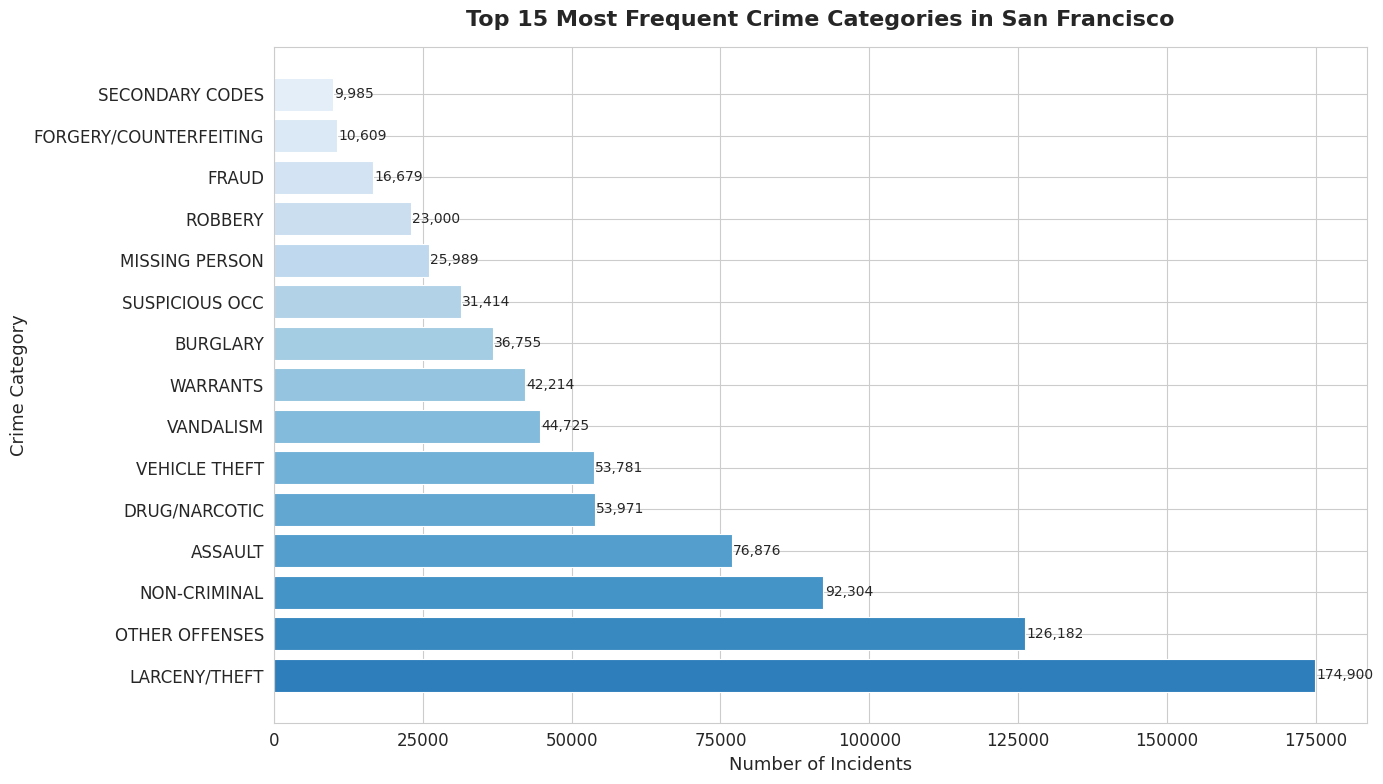

Graph 1 saved: crime_by_category.png


In [ ]:
df_viz = pd.read_csv(dataset_path)
df_viz.dropna(inplace=True)

plt.figure(figsize=(14, 8))
crime_counts = df_viz['Category'].value_counts().head(15)

colors = plt.cm.Blues_r(
    np.linspace(0.3, 0.9, len(crime_counts)))

bars = plt.barh(crime_counts.index,
                crime_counts.values,
                color=colors,
                edgecolor='white',
                linewidth=0.8)

for bar, val in zip(bars, crime_counts.values):
    plt.text(bar.get_width() + 200,
             bar.get_y() + bar.get_height() / 2,
             f'{val:,}',
             va='center', fontsize=10)

plt.title('Top 15 Most Frequent Crime Categories '
          'in San Francisco',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Incidents', fontsize=13)
plt.ylabel('Crime Category',      fontsize=13)
plt.tight_layout()
plt.savefig(output_path + 'crime_by_category.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph 1 saved: crime_by_category.png")

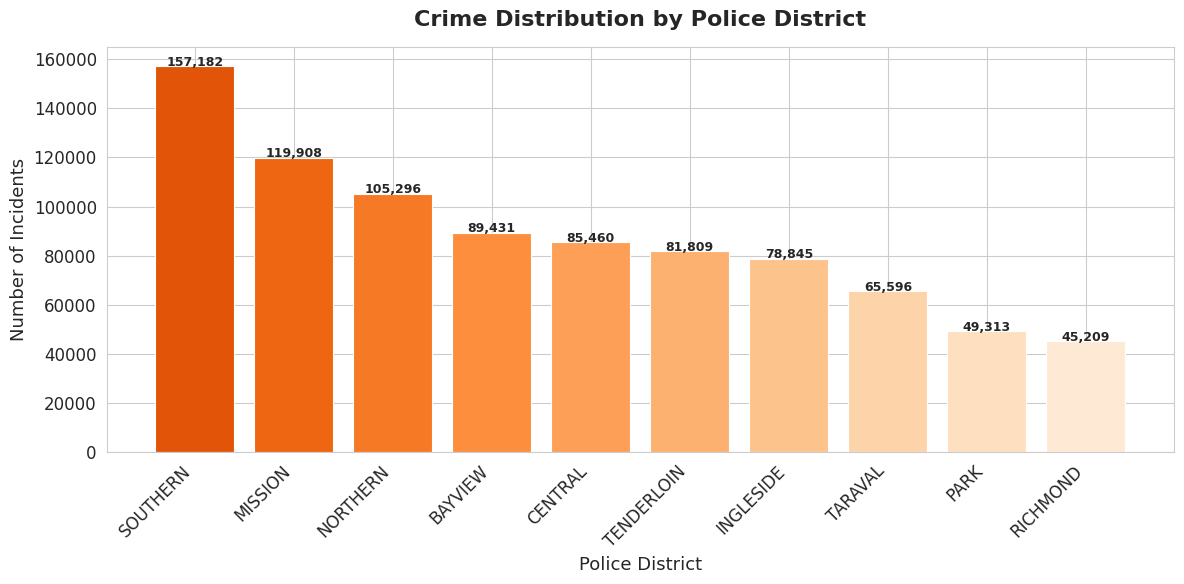

Graph 2 saved: crime_by_district.png


In [ ]:
plt.figure(figsize=(12, 6))
dist_counts = df_viz['PdDistrict'].value_counts()

colors2 = plt.cm.Oranges_r(
    np.linspace(0.3, 0.9, len(dist_counts)))

bars2 = plt.bar(dist_counts.index,
                dist_counts.values,
                color=colors2,
                edgecolor='white',
                linewidth=0.8)

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200,
             f'{int(bar.get_height()):,}',
             ha='center', fontsize=9,
             fontweight='bold')

plt.title('Crime Distribution by Police District',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Police District', fontsize=13)
plt.ylabel('Number of Incidents', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(output_path + 'crime_by_district.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph 2 saved: crime_by_district.png")

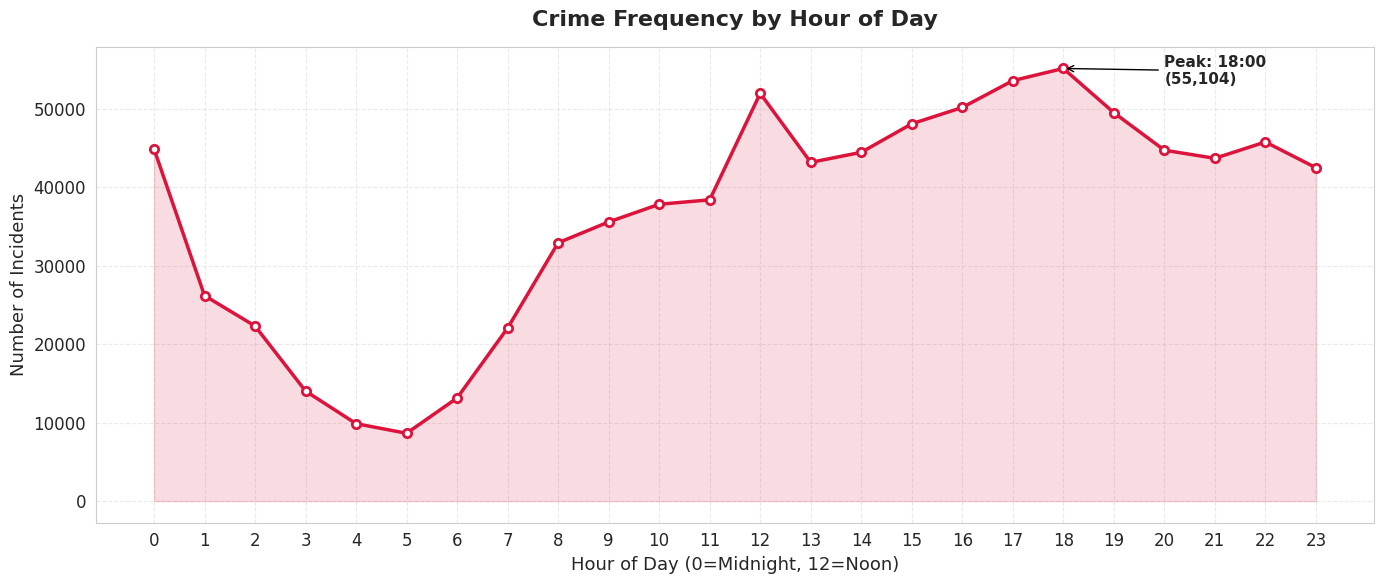

Graph 3 saved: crime_by_hour.png


In [ ]:
df_viz['Hour_viz'] = pd.to_datetime(
    df_viz['Dates']).dt.hour
hour_counts = df_viz['Hour_viz'].value_counts(
    ).sort_index()

plt.figure(figsize=(14, 6))
plt.plot(hour_counts.index,
         hour_counts.values,
         color='crimson',
         linewidth=2.5,
         marker='o',
         markersize=6,
         markerfacecolor='white',
         markeredgewidth=2)

plt.fill_between(hour_counts.index,
                 hour_counts.values,
                 alpha=0.15,
                 color='crimson')

peak_hour = hour_counts.idxmax()
peak_val  = hour_counts.max()
plt.annotate(f'Peak: {peak_hour}:00\n({peak_val:,})',
             xy=(peak_hour, peak_val),
             xytext=(peak_hour + 2, peak_val - 2000),
             arrowprops=dict(arrowstyle='->',
                             color='black'),
             fontsize=11, fontweight='bold')

plt.title('Crime Frequency by Hour of Day',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hour of Day (0=Midnight, 12=Noon)',
           fontsize=13)
plt.ylabel('Number of Incidents', fontsize=13)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.savefig(output_path + 'crime_by_hour.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph 3 saved: crime_by_hour.png")

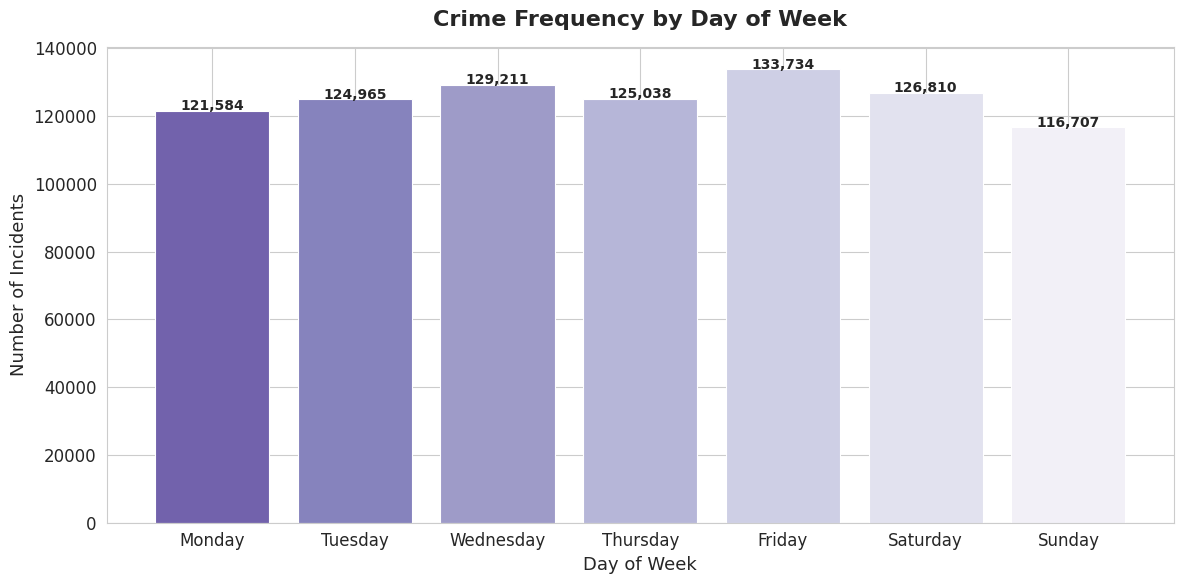

Graph 4 saved: crime_by_day.png


In [ ]:
day_order  = ['Monday', 'Tuesday', 'Wednesday',
               'Thursday', 'Friday',
               'Saturday', 'Sunday']
day_counts = df_viz['DayOfWeek'].value_counts(
    ).reindex(day_order)

colors3 = plt.cm.Purples_r(
    np.linspace(0.3, 0.9, 7))

plt.figure(figsize=(12, 6))
bars3 = plt.bar(day_counts.index,
                day_counts.values,
                color=colors3,
                edgecolor='white',
                linewidth=0.8)

for bar in bars3:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200,
             f'{int(bar.get_height()):,}',
             ha='center', fontsize=10,
             fontweight='bold')

plt.title('Crime Frequency by Day of Week',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Day of Week', fontsize=13)
plt.ylabel('Number of Incidents', fontsize=13)
plt.tight_layout()
plt.savefig(output_path + 'crime_by_day.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph 4 saved: crime_by_day.png")

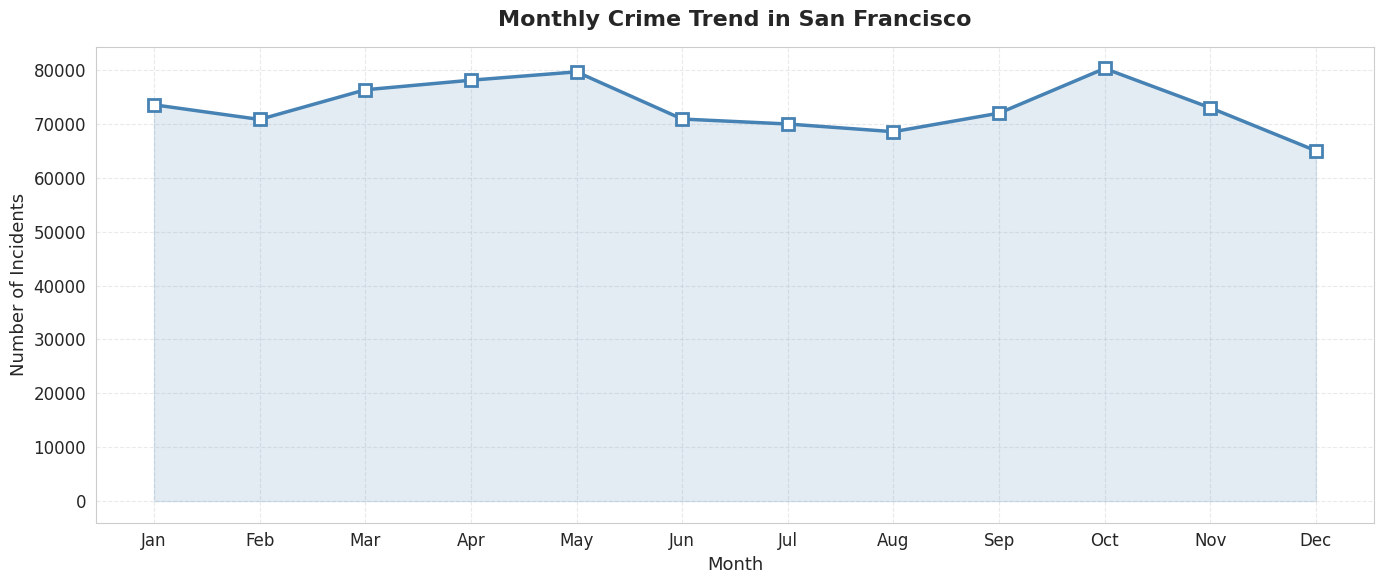

Graph 5 saved: crime_by_month.png


In [ ]:
df_viz['Month_viz'] = pd.to_datetime(
    df_viz['Dates']).dt.month
monthly_counts = df_viz['Month_viz'].value_counts(
    ).sort_index()
month_names    = ['Jan', 'Feb', 'Mar', 'Apr',
                   'May', 'Jun', 'Jul', 'Aug',
                   'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(14, 6))
plt.plot(month_names,
         monthly_counts.values,
         color='steelblue',
         linewidth=2.5,
         marker='s',
         markersize=8,
         markerfacecolor='white',
         markeredgewidth=2)

plt.fill_between(range(12),
                 monthly_counts.values,
                 alpha=0.15,
                 color='steelblue')

plt.title('Monthly Crime Trend in San Francisco',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=13)
plt.ylabel('Number of Incidents', fontsize=13)
plt.xticks(range(12), month_names)
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.savefig(output_path + 'crime_by_month.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph 5 saved: crime_by_month.png")

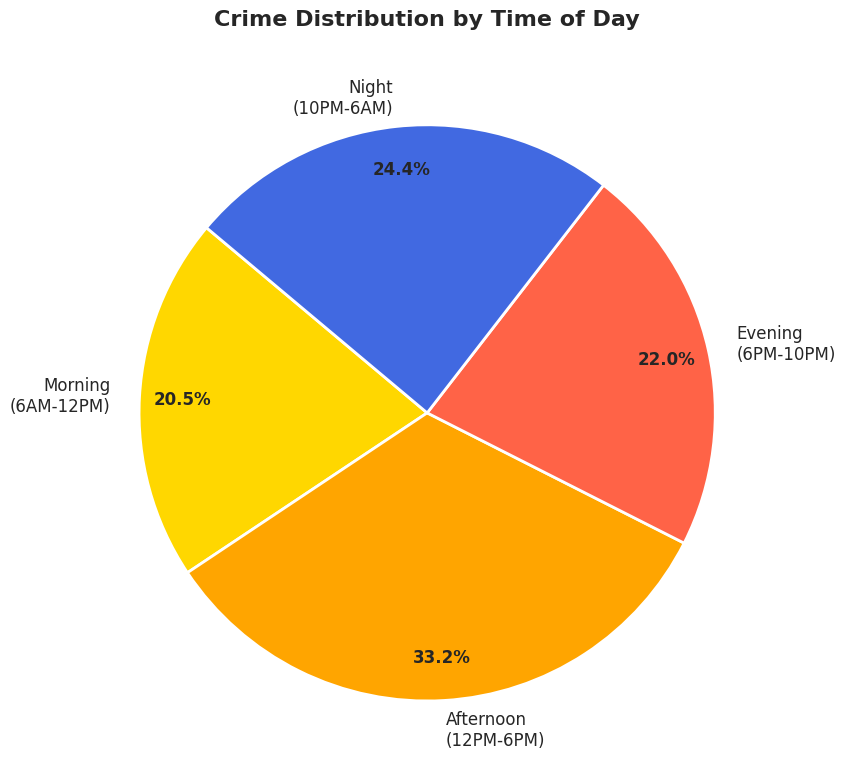

Graph 6 saved: crime_by_timeofday.png


In [ ]:
tod_data   = df['TimeOfDay'].value_counts().sort_index()
tod_labels = ['Morning\n(6AM-12PM)',
               'Afternoon\n(12PM-6PM)',
               'Evening\n(6PM-10PM)',
               'Night\n(10PM-6AM)']
tod_colors = ['#FFD700', '#FFA500',
               '#FF6347', '#4169E1']

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    tod_data.values,
    labels=tod_labels,
    colors=tod_colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.85)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

plt.title('Crime Distribution by Time of Day',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(output_path + 'crime_by_timeofday.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph 6 saved: crime_by_timeofday.png")

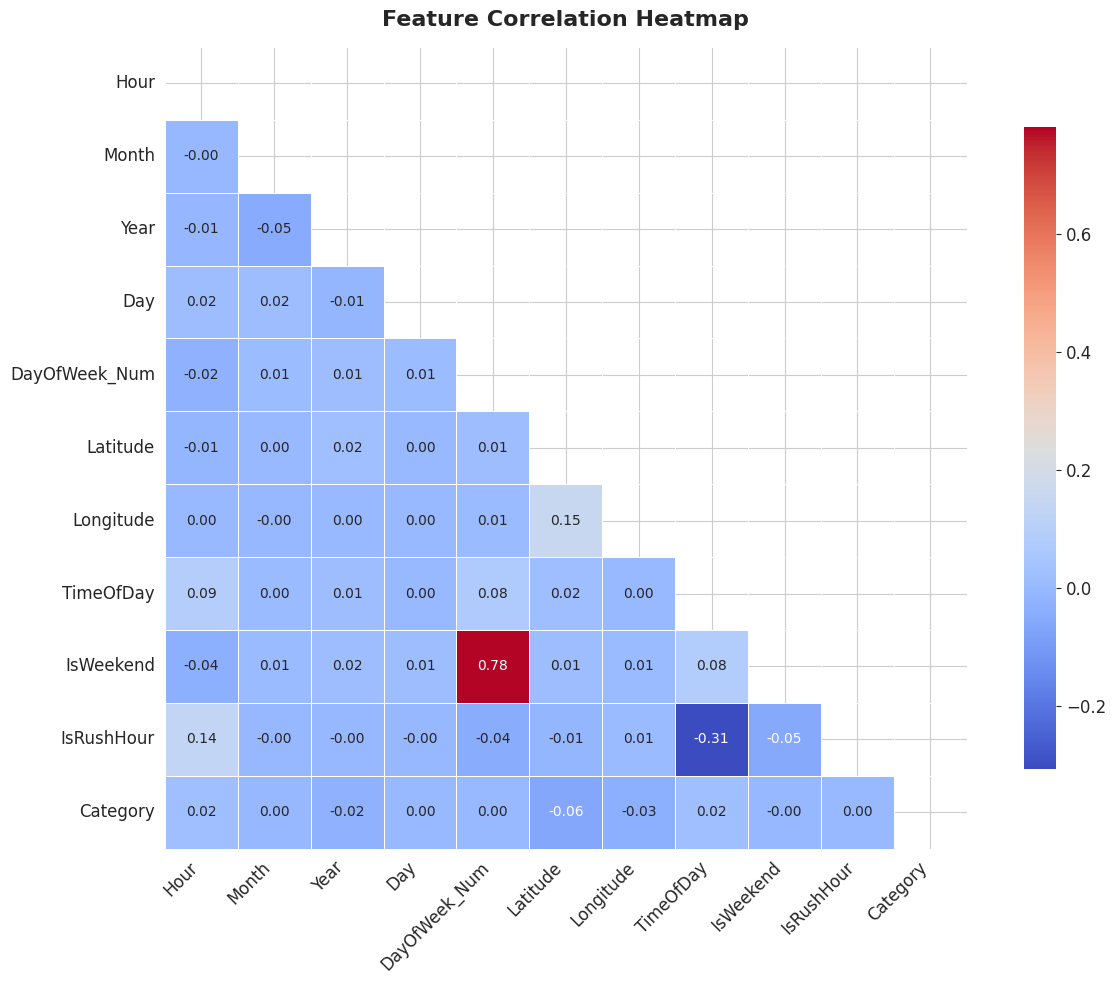

Graph 7 saved: correlation_heatmap.png


In [ ]:
num_df = df[['Hour', 'Month', 'Year', 'Day',
              'DayOfWeek_Num', 'Latitude',
              'Longitude', 'TimeOfDay',
              'IsWeekend', 'IsRushHour',
              'Category']].copy()

corr_matrix = num_df.corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            mask=mask,
            linewidths=0.5,
            square=True,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})

plt.title('Feature Correlation Heatmap',
          fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(output_path + 'correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph 7 saved: correlation_heatmap.png")

In [ ]:
print("Generating Crime Hotspot Map...")

# Load and clean map data
df_map = pd.read_csv(dataset_path)
df_map.dropna(subset=['X', 'Y'], inplace=True)
df_map.rename(columns={'X': 'Longitude',
                        'Y': 'Latitude'}, inplace=True)

df_map = df_map[
    (df_map['Latitude']  >= 37.70) &
    (df_map['Latitude']  <= 37.83) &
    (df_map['Longitude'] >= -122.53) &
    (df_map['Longitude'] <= -122.35)]

print(f"Valid map records: {len(df_map):,}")

# Create base map
sf_center = [37.7749, -122.4194]
sf_map    = folium.Map(
    location=sf_center,
    zoom_start=12,
    tiles='CartoDB positron')

# Sample for heatmap
sample_size = min(50000, len(df_map))
df_sample   = df_map.sample(n=sample_size,
                              random_state=42)

heat_data = [[row['Latitude'], row['Longitude']]
             for _, row in df_sample.iterrows()]

# Add heatmap layer
HeatMap(
    heat_data,
    radius=10,
    blur=15,
    max_zoom=13,
    min_opacity=0.3,
    gradient={0.2: 'blue',
              0.4: 'cyan',
              0.6: 'lime',
              0.8: 'yellow',
              1.0: 'red'}
).add_to(sf_map)

# Add title
title_html = '''
<h3 align="center"
    style="font-size:18px;
           font-family:Arial;
           color:#333">
San Francisco Crime Hotspot Heatmap
</h3>'''
sf_map.get_root().html.add_child(
    folium.Element(title_html))

# Save map
map_path = output_path + 'sf_crime_heatmap.html'
sf_map.save(map_path)
print(f"Heatmap saved to: {map_path}")
print("Displaying map below:")

# Display inside Colab
display(sf_map)

Generating Crime Hotspot Map...
Valid map records: 877,982
Heatmap saved to: /content/drive/MyDrive/SF_Crime_Project/outputs/sf_crime_heatmap.html
Displaying map below:


Crime Density by Police District:
  District  Crime_Count  Percentage
  SOUTHERN       157174       17.90
   MISSION       119907       13.66
  NORTHERN       105284       11.99
   BAYVIEW        89422       10.18
   CENTRAL        85455        9.73
TENDERLOIN        81794        9.32
 INGLESIDE        78841        8.98
   TARAVAL        65592        7.47
      PARK        49311        5.62
  RICHMOND        45202        5.15


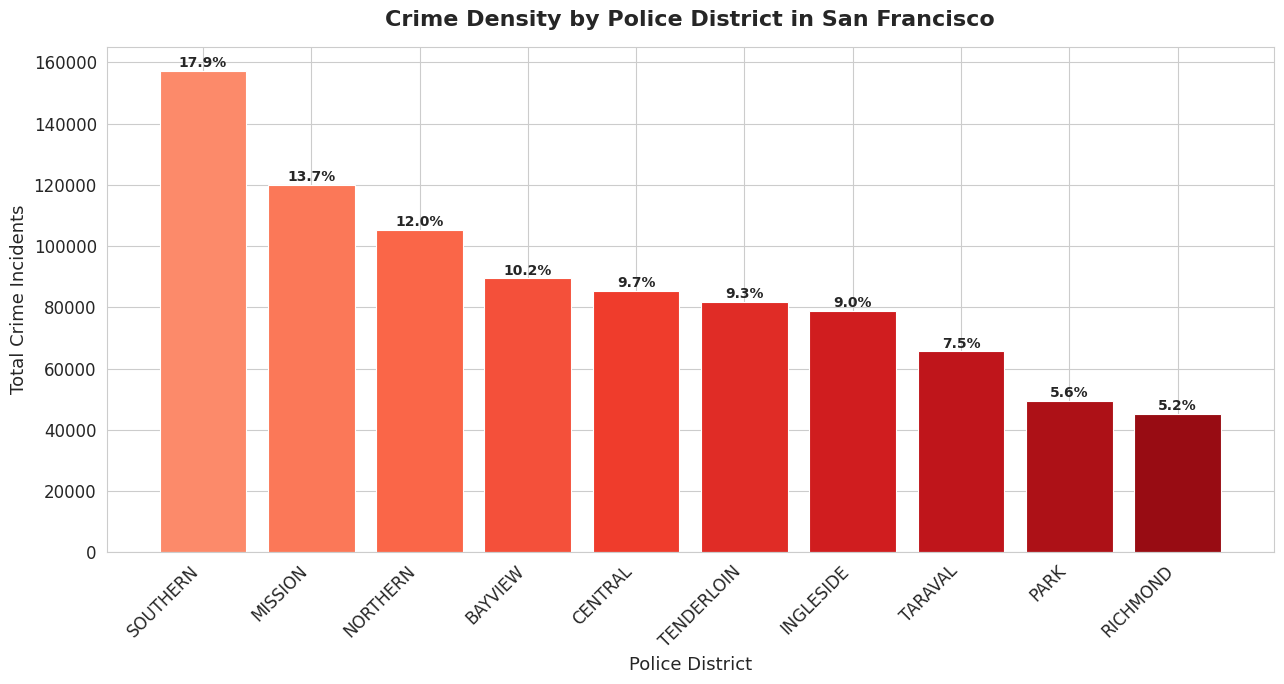

Graph 8 saved: district_density.png


In [ ]:
district_crime = df_map['PdDistrict'].value_counts(
    ).reset_index()
district_crime.columns = ['District', 'Crime_Count']
district_crime['Percentage'] = (
    district_crime['Crime_Count'] /
    district_crime['Crime_Count'].sum() * 100
).round(2)

print("Crime Density by Police District:")
print(district_crime.to_string(index=False))

plt.figure(figsize=(13, 7))
reds = plt.cm.Reds(
    np.linspace(0.4, 0.9, len(district_crime)))

bars4 = plt.bar(
    district_crime['District'],
    district_crime['Crime_Count'],
    color=reds,
    edgecolor='white',
    linewidth=0.8)

for bar, pct in zip(bars4,
                     district_crime['Percentage']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f'{pct:.1f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold')

plt.title('Crime Density by Police District '
          'in San Francisco',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Police District', fontsize=13)
plt.ylabel('Total Crime Incidents', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(output_path + 'district_density.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph 8 saved: district_density.png")

In [ ]:
import pandas as pd
import numpy as np

# Load the new dataset
df_new = pd.read_csv(
    '/content/drive/MyDrive/'
    'SF_Crime_Project/sfcrime_new.csv')

print("Shape:", df_new.shape)
print("\nColumns:", df_new.columns.tolist())
print("\nCategory distribution:")
print(df_new['Category'].value_counts().head(10))
print("\nTotal categories:", df_new['Category'].nunique())

Shape: (878049, 9)

Columns: ['Dates', 'Category', 'Descript', 'DayOfWeek', 'PdDistrict', 'Resolution', 'Address', 'X', 'Y']

Category distribution:
Category
LARCENY/THEFT     174900
OTHER OFFENSES    126182
NON-CRIMINAL       92304
ASSAULT            76876
DRUG/NARCOTIC      53971
VEHICLE THEFT      53781
VANDALISM          44725
WARRANTS           42214
BURGLARY           36755
SUSPICIOUS OCC     31414
Name: count, dtype: int64

Total categories: 39


In [ ]:
from sklearn.preprocessing   import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Keep ONLY top 3 categories
# 3 categories is much easier to classify accurately
top3 = df_new['Category'].value_counts(
    ).head(3).index.tolist()

print("Top 3 categories:")
for cat in top3:
    n = (df_new['Category'] == cat).sum()
    print(f"  {cat}: {n:,}")

# Filter
df3 = df_new[df_new['Category'].isin(top3)].copy()

# Balance — equal records per category
min_n = df3['Category'].value_counts().min()
print(f"\nUsing {min_n:,} records per category")
print(f"Total: {min_n * 3:,} records")

balanced = []
for cat in top3:
    sample = df3[
        df3['Category'] == cat].sample(
        n=min_n, random_state=42)
    balanced.append(sample)

df3 = pd.concat(balanced).sample(
    frac=1, random_state=42
    ).reset_index(drop=True)

print("\nBalanced distribution:")
print(df3['Category'].value_counts())

# Preprocess
df3['Dates'] = pd.to_datetime(df3['Dates'])
df3['Hour']  = df3['Dates'].dt.hour
df3['Month'] = df3['Dates'].dt.month
df3['Year']  = df3['Dates'].dt.year
df3['Day']   = df3['Dates'].dt.day
df3['DayOfWeek_Num'] = df3['Dates'].dt.dayofweek
df3['Quarter']       = df3['Dates'].dt.quarter
df3['WeekOfYear']    = df3['Dates'].dt.isocalendar(
                        ).week.astype(int)

# Fix coordinate column names
if 'X' in df3.columns:
    df3.rename(columns={'X': 'Longitude',
                         'Y': 'Latitude'},
                inplace=True)

# Remove invalid coordinates
df3 = df3[
    (df3['Latitude']  >= 37.70) &
    (df3['Latitude']  <= 37.83) &
    (df3['Longitude'] >= -122.53) &
    (df3['Longitude'] <= -122.35)]

# Feature engineering
df3['TimeOfDay'] = df3['Hour'].apply(
    lambda h: 0 if 6<=h<12
    else 1 if 12<=h<18
    else 2 if 18<=h<22
    else 3)

df3['IsWeekend']  = df3['DayOfWeek_Num'].apply(
    lambda x: 1 if x >= 5 else 0)

df3['IsRushHour'] = df3['Hour'].apply(
    lambda h: 1 if (7<=h<=9) or (16<=h<=19) else 0)

# Encode district
le_dist       = LabelEncoder()
df3['PdDistrict'] = le_dist.fit_transform(
    df3['PdDistrict'].astype(str))

# Encode target
le3          = LabelEncoder()
df3['Target'] = le3.fit_transform(df3['Category'])

print("\nCategory encoding:")
for i, name in enumerate(le3.classes_):
    count = (df3['Target'] == i).sum()
    print(f"  {i} = {name}: {count:,}")

# Normalize
scaler   = MinMaxScaler()
num_cols = ['Latitude', 'Longitude',
             'Hour', 'Month', 'Year', 'Day']
df3[num_cols] = scaler.fit_transform(df3[num_cols])

# Features
feat_cols = ['Hour', 'Month', 'Year', 'Day',
             'DayOfWeek_Num', 'WeekOfYear',
             'Quarter', 'TimeOfDay',
             'IsWeekend', 'IsRushHour',
             'PdDistrict', 'Latitude', 'Longitude']

X3 = df3[feat_cols]
y3 = df3['Target']

# Split
X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
    X3, y3,
    test_size=0.25,
    random_state=42,
    stratify=y3)

print(f"\nTraining: {X_tr3.shape[0]:,}")
print(f"Testing : {X_te3.shape[0]:,}")
print("Ready to train!")

Top 3 categories:
  LARCENY/THEFT: 174,900
  OTHER OFFENSES: 126,182
  NON-CRIMINAL: 92,304

Using 92,304 records per category
Total: 276,912 records

Balanced distribution:
Category
NON-CRIMINAL      92304
OTHER OFFENSES    92304
LARCENY/THEFT     92304
Name: count, dtype: int64

Category encoding:
  0 = LARCENY/THEFT: 92,297
  1 = NON-CRIMINAL: 92,300
  2 = OTHER OFFENSES: 92,295

Training: 207,669
Testing : 69,223
Ready to train!


Training all 5 models on Top 3 categories...

[1/5] Logistic Regression...
      Accuracy: 41.96%
[2/5] Decision Tree...
      Accuracy: 48.76%
[3/5] Random Forest...
      Accuracy : 50.73%
      OOB Score: 50.59%
[4/5] Naive Bayes...
      Accuracy: 41.95%
[5/5] K-Nearest Neighbors...
      Accuracy: 40.42%
   FINAL RANKED RESULTS — TOP 3 CATEGORIES
                 Model  Accuracy (%)  Precision  Recall  F1-Score
1        Random Forest         50.73     0.5051  0.5073    0.5050
2        Decision Tree         48.76     0.4886  0.4876    0.4880
3  Logistic Regression         41.96     0.4183  0.4196    0.4180
4          Naive Bayes         41.95     0.4191  0.4195    0.4162
5  K-Nearest Neighbors         40.42     0.4046  0.4042    0.4033


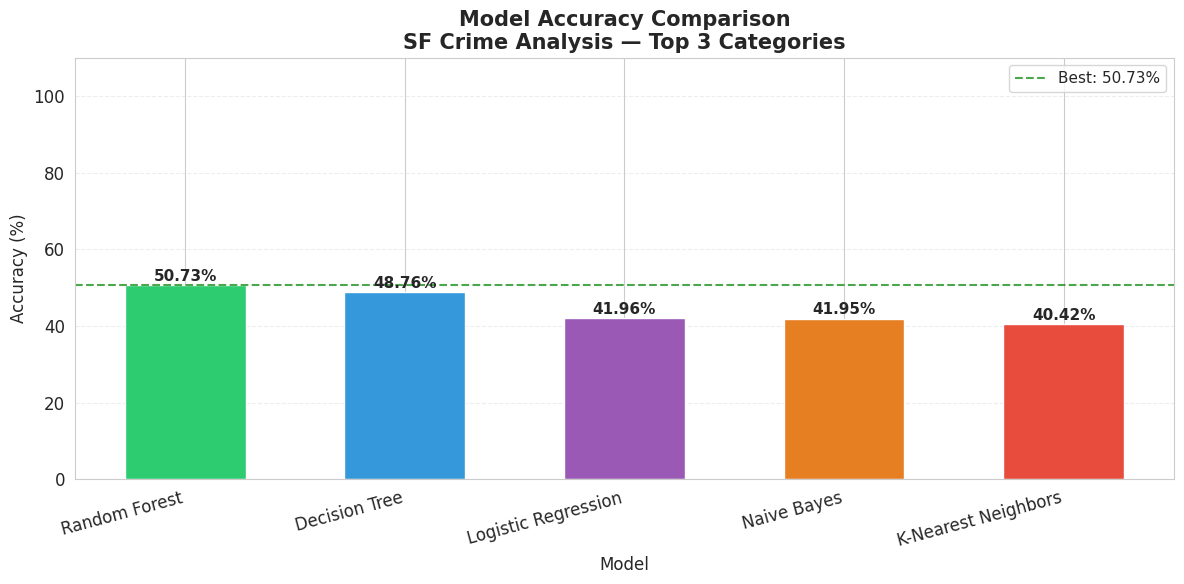

Accuracy chart saved!


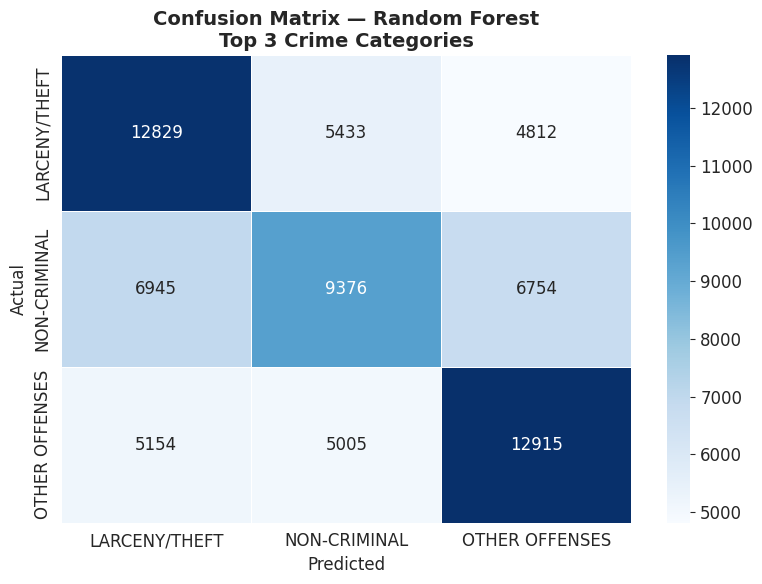

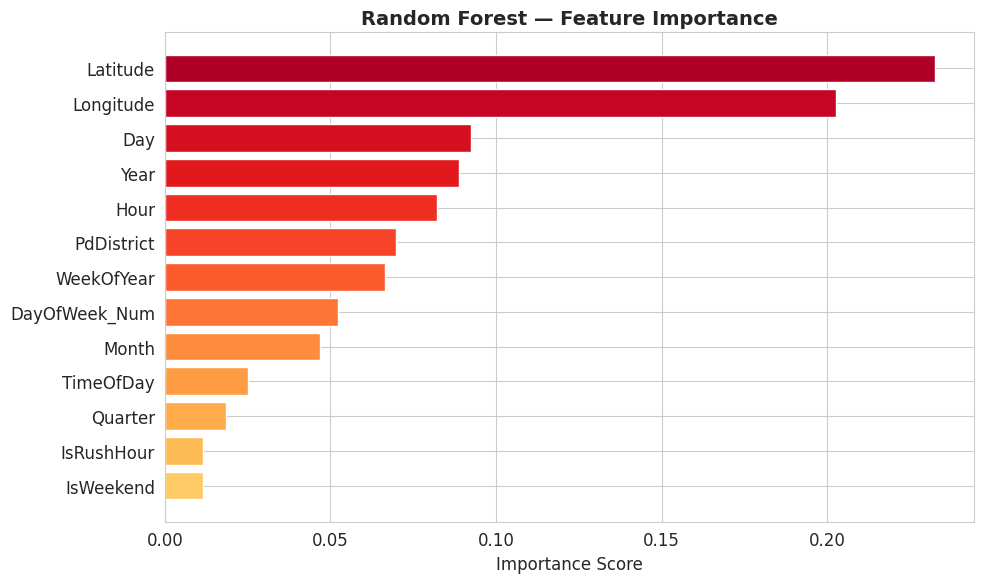

All charts saved!

Classification Report — Random Forest:
                precision    recall  f1-score   support

 LARCENY/THEFT       0.51      0.56      0.53     23074
  NON-CRIMINAL       0.47      0.41      0.44     23075
OTHER OFFENSES       0.53      0.56      0.54     23074

      accuracy                           0.51     69223
     macro avg       0.51      0.51      0.50     69223
  weighted avg       0.51      0.51      0.50     69223

Best model saved!


In [ ]:
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.metrics       import (accuracy_score,
                                    precision_score,
                                    recall_score,
                                    f1_score,
                                    confusion_matrix,
                                    classification_report)
import matplotlib.pyplot as plt
import seaborn            as sns
import pickle, os
import numpy as np

output_path = (
    '/content/drive/MyDrive/'
    'SF_Crime_Project/outputs/')
os.makedirs(output_path, exist_ok=True)

print("Training all 5 models on Top 3 categories...")


# Train models
print("\n[1/5] Logistic Regression...")
lr3 = LogisticRegression(
    max_iter=1000, random_state=42, n_jobs=-1)
lr3.fit(X_tr3, y_tr3)
lr3_pred = lr3.predict(X_te3)
print(f"      Accuracy: "
      f"{accuracy_score(y_te3, lr3_pred)*100:.2f}%")

print("[2/5] Decision Tree...")
dt3 = DecisionTreeClassifier(
    max_depth=15, random_state=42)
dt3.fit(X_tr3, y_tr3)
dt3_pred = dt3.predict(X_te3)
print(f"      Accuracy: "
      f"{accuracy_score(y_te3, dt3_pred)*100:.2f}%")

print("[3/5] Random Forest...")
rf3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    oob_score=True,
    random_state=42)
rf3.fit(X_tr3, y_tr3)
rf3_pred = rf3.predict(X_te3)
print(f"      Accuracy : "
      f"{accuracy_score(y_te3, rf3_pred)*100:.2f}%")
print(f"      OOB Score: "
      f"{rf3.oob_score_*100:.2f}%")

print("[4/5] Naive Bayes...")
nb3 = GaussianNB()
nb3.fit(X_tr3, y_tr3)
nb3_pred = nb3.predict(X_te3)
print(f"      Accuracy: "
      f"{accuracy_score(y_te3, nb3_pred)*100:.2f}%")

print("[5/5] K-Nearest Neighbors...")
knn3 = KNeighborsClassifier(
    n_neighbors=7, n_jobs=-1)
knn3.fit(X_tr3, y_tr3)
knn3_pred = knn3.predict(X_te3)
print(f"      Accuracy: "
      f"{accuracy_score(y_te3, knn3_pred)*100:.2f}%")

# Results table
all_p = {
    'Random Forest'      : rf3_pred,
    'Decision Tree'      : dt3_pred,
    'Logistic Regression': lr3_pred,
    'Naive Bayes'        : nb3_pred,
    'K-Nearest Neighbors': knn3_pred
}

rows = []
for name, preds in all_p.items():
    rows.append({
        'Model'       : name,
        'Accuracy (%)': round(
            accuracy_score(y_te3, preds)*100, 2),
        'Precision'   : round(
            precision_score(y_te3, preds,
                            average='weighted',
                            zero_division=0), 4),
        'Recall'      : round(
            recall_score(y_te3, preds,
                          average='weighted',
                          zero_division=0), 4),
        'F1-Score'    : round(
            f1_score(y_te3, preds,
                      average='weighted',
                      zero_division=0), 4)
    })

final_df3 = pd.DataFrame(rows).sort_values(
    'Accuracy (%)', ascending=False)
final_df3.reset_index(drop=True, inplace=True)
final_df3.index += 1


print("   FINAL RANKED RESULTS — TOP 3 CATEGORIES")

print(final_df3.to_string())

# Accuracy chart
plt.figure(figsize=(12, 6))
colors = ['#2ECC71', '#3498DB', '#9B59B6',
           '#E67E22', '#E74C3C']
bars   = plt.bar(
    final_df3['Model'],
    final_df3['Accuracy (%)'],
    color=colors,
    edgecolor='white',
    width=0.55)

for bar, acc in zip(bars,
                     final_df3['Accuracy (%)']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{acc:.2f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold')

plt.axhline(
    y=max(final_df3['Accuracy (%)']),
    color='green', linestyle='--',
    linewidth=1.5, alpha=0.7,
    label=f"Best: "
          f"{max(final_df3['Accuracy (%)']):.2f}%")

plt.title('Model Accuracy Comparison\n'
          'SF Crime Analysis — Top 3 Categories',
          fontsize=15, fontweight='bold')
plt.xlabel('Model',        fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 110)
plt.legend(fontsize=11)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.35, linestyle='--')
plt.tight_layout()
plt.savefig(output_path + 'model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Accuracy chart saved!")

# Confusion matrix
plt.figure(figsize=(8, 6))
cm3 = confusion_matrix(y_te3, rf3_pred)
sns.heatmap(cm3,
            annot=True,
            fmt='d',
            cmap='Blues',
            linewidths=0.5,
            xticklabels=le3.classes_,
            yticklabels=le3.classes_)
plt.title('Confusion Matrix — Random Forest\n'
          'Top 3 Crime Categories',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual',    fontsize=12)
plt.tight_layout()
plt.savefig(output_path + 'confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Feature importance
rf_imp = pd.DataFrame({
    'Feature'   : feat_cols,
    'Importance': rf3.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
clrs = plt.cm.YlOrRd(
    np.linspace(0.3, 0.9, len(rf_imp)))
plt.barh(rf_imp['Feature'],
          rf_imp['Importance'],
          color=clrs,
          edgecolor='white')
plt.title('Random Forest — Feature Importance',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig(output_path + 'feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("All charts saved!")

# Classification report
print("\nClassification Report — Random Forest:")
print(classification_report(
    y_te3, rf3_pred,
    target_names=le3.classes_,
    zero_division=0))

# Save model
with open(output_path + 'crime_model.pkl', 'wb') as f:
    pickle.dump(rf3, f)
print("Best model saved!")